# Random Forest Classification - Employee Attrition Prediction

## Business Problem

Employee attrition is one of the biggest challenges for organizations. Losing experienced employees increases hiring costs, training expenses, and reduces overall productivity.

The HR department wants to predict which employees are likely to leave so that retention strategies can be implemented proactively.

## Objective

Build a Random Forest Classification model to predict employee attrition and identify the most influential factors affecting employee turnover.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
# import datset
df = pd.read_csv("dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.shape

(1470, 35)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [9]:
df['Attrition'].value_counts()

No     1233
Yes     237
Name: Attrition, dtype: int64

In [10]:
df['Attrition'].value_counts(normalize=True)

No     0.838776
Yes    0.161224
Name: Attrition, dtype: float64

In [11]:
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [12]:
# Remove constant and identifier columns
df.drop(columns = ['EmployeeCount',
        'EmployeeNumber',
        'Over18',
        'StandardHours'],inplace = True)

In [13]:
df.shape

(1470, 31)

In [14]:
#Separate Numerical and Categorical Columns
num_cols = df.select_dtypes(include = np.number).columns
cat_cols = df.select_dtypes(include = 'object').columns
print("Numerical Columns:", len(num_cols))
print("Categorical Columns:", len(cat_cols))

Numerical Columns: 23
Categorical Columns: 8


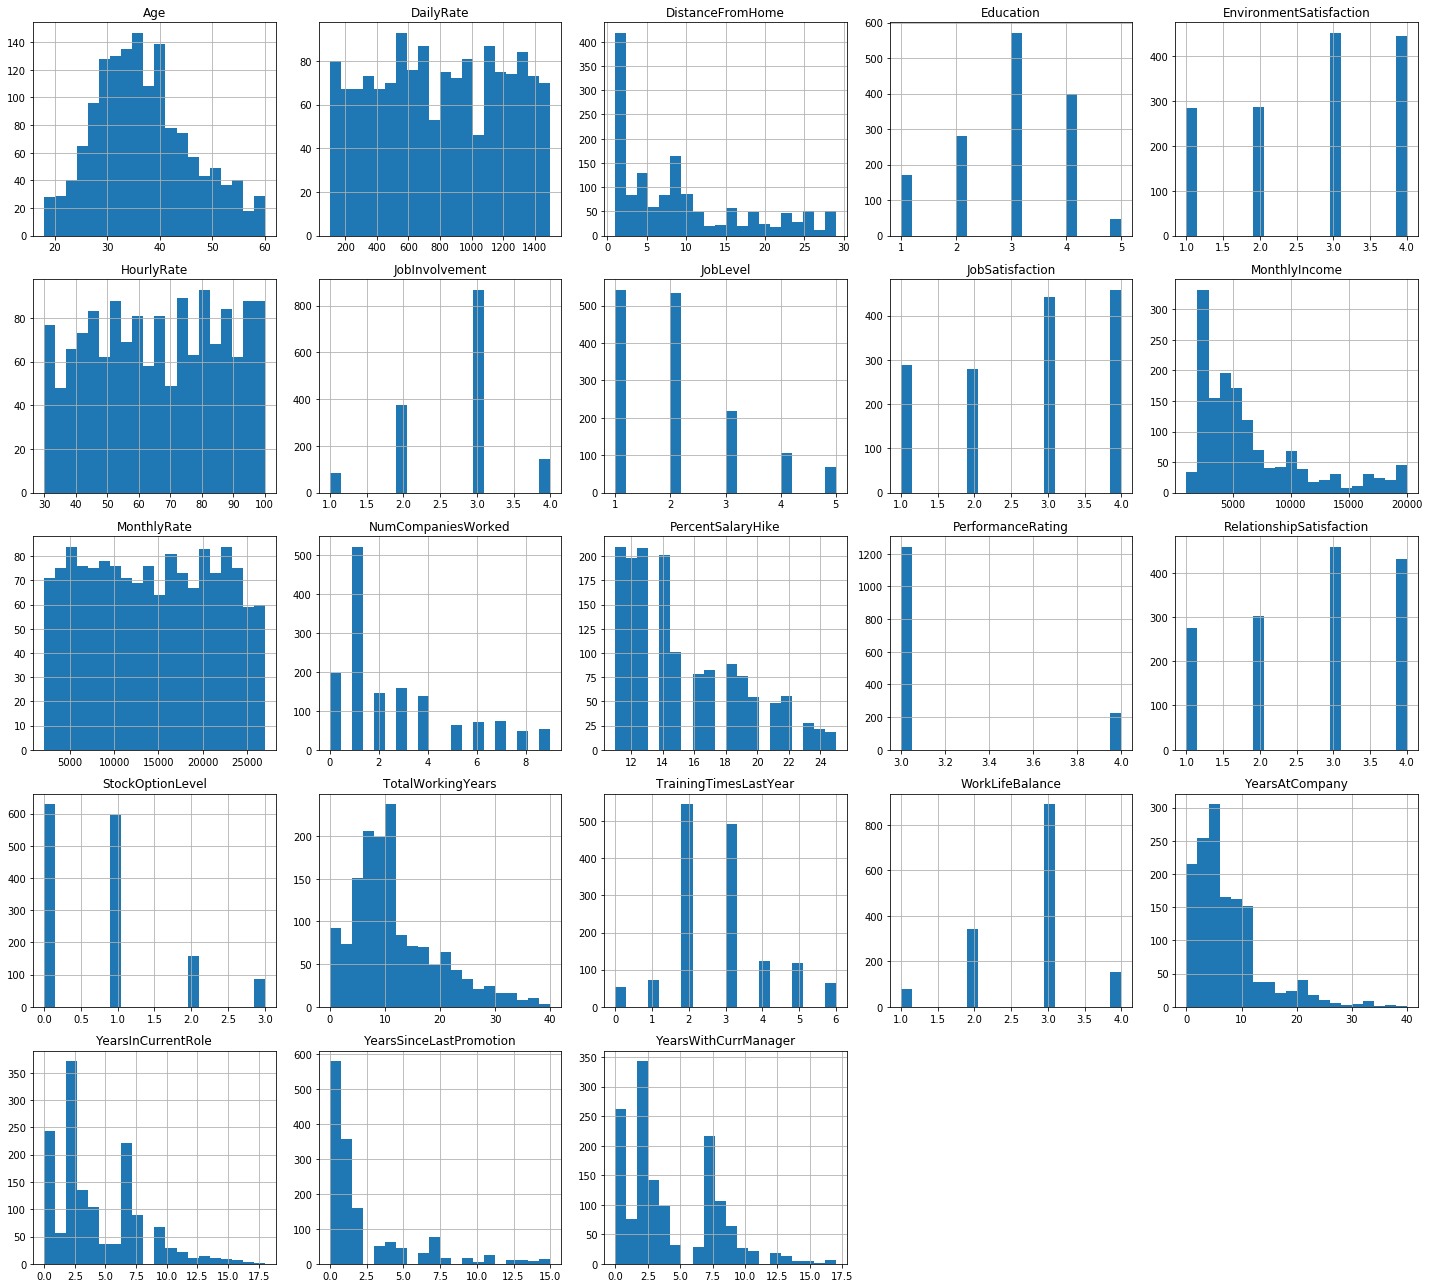

In [15]:
# Numerical distributions - 1

df[num_cols].hist(
    figsize=(20,18),
    bins=20
)

plt.tight_layout()

plt.show()

Do we need a normal distribution for Random Forest?

✅ Answer

No.

Unlike Linear Regression, Random Forest does not assume normality.

Therefore, skewed distributions are generally not a problem.

Do we need Feature Scaling?

✅ Answer

No.

Random Forest is based on Decision Trees.

Trees split based on thresholds, not distances.

Therefore:

No StandardScaler
No MinMaxScaler

###### Business insight

Age : 
The company appears to have a relatively young workforce.

Salary Features:
DailyRate
HourlyRate
MonthlyRate
MonthlyIncomeMost employees earn lower salaries, while a small number earn significantly higher salaries (likely senior managers or executives).

Experience Features :
TotalWorkingYears
YearsAtCompany
YearsInCurrentRole
YearsWithCurrManager
YearsSinceLastPromotion
All are right-skewed.
Most employees have relatively few years of experience, with fewer long-tenured employees.

Rating Features : 
JobSatisfaction
EnvironmentSatisfaction
JobInvolvement
WorkLifeBalance
RelationshipSatisfaction
These are discrete ordinal variables, not continuous variables.
Their values are mostly between 1 and 4.
This is expected because they come from employee surveys

Performance Rating:
This one is interesting.
Almost everyone has only two ratings.



#### Why are we plotting Boxplots?

Before building any machine learning model, we check whether numerical features contain outliers.

Outliers can:

Affect model performance.
Indicate data entry errors.
Represent genuine rare observations.

Different algorithms handle outliers differently.

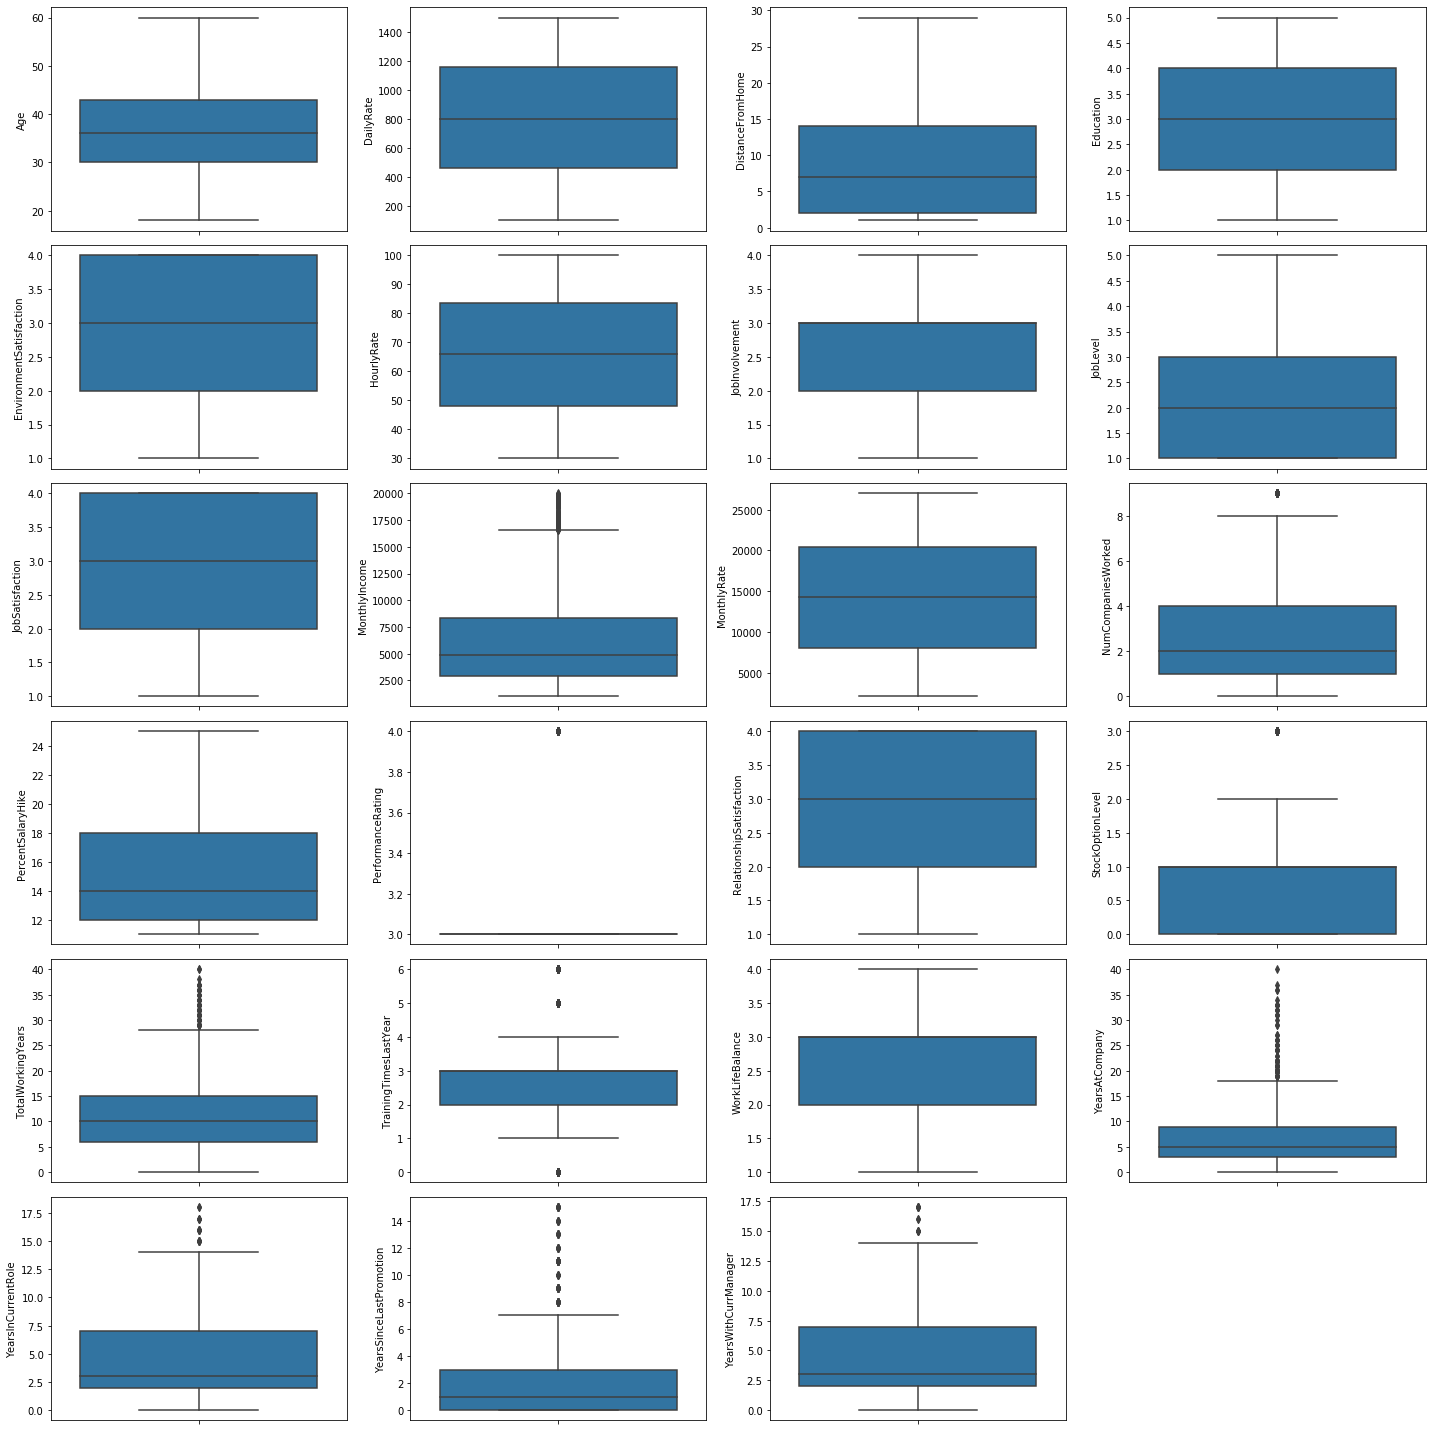

In [16]:
#  Numerical distributions - 2

plt.figure(figsize=(20,20))

for i, col in enumerate(num_cols):
    plt.subplot(6,4,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

Age : No significant outliers.

Salary Features : MonthlyIncome : There are several high-income outliers.These are likely senior managers, executives, or highly experienced employees.

TotalWorkingYears : Many employees have much higher experience than the majority, genuine data.

YearsAtCompany : Large number of outliers, again ,these are employees who have stayed for many years, completely genuine.

YearsInCurrentRole : Several employees have spent many years in the same role.

YearsSinceLastPromotion : Many employees haven't been promoted for a long time.

YearsWithCurrManager : Some employees have worked with the same manager for many years.

TrainingTimesLastYear : A few employees received many training sessions.

###### Overall Outlier Summary

Features with noticeable outliers
MonthlyIncome ,
TotalWorkingYears ,
YearsAtCompany ,
YearsInCurrentRole ,
YearsSinceLastPromotion ,
YearsWithCurrManager ,
TrainingTimesLastYear ,
NumCompaniesWorked

### Categorical distributions

For numerical variables, we looked at:

Distribution
Skewness
Outliers

For categorical variables, we want to understand:

Frequency of each category
Class imbalance
Rare categories
Business meaning

In [17]:
cat_cols

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')

### Univariate Analysis

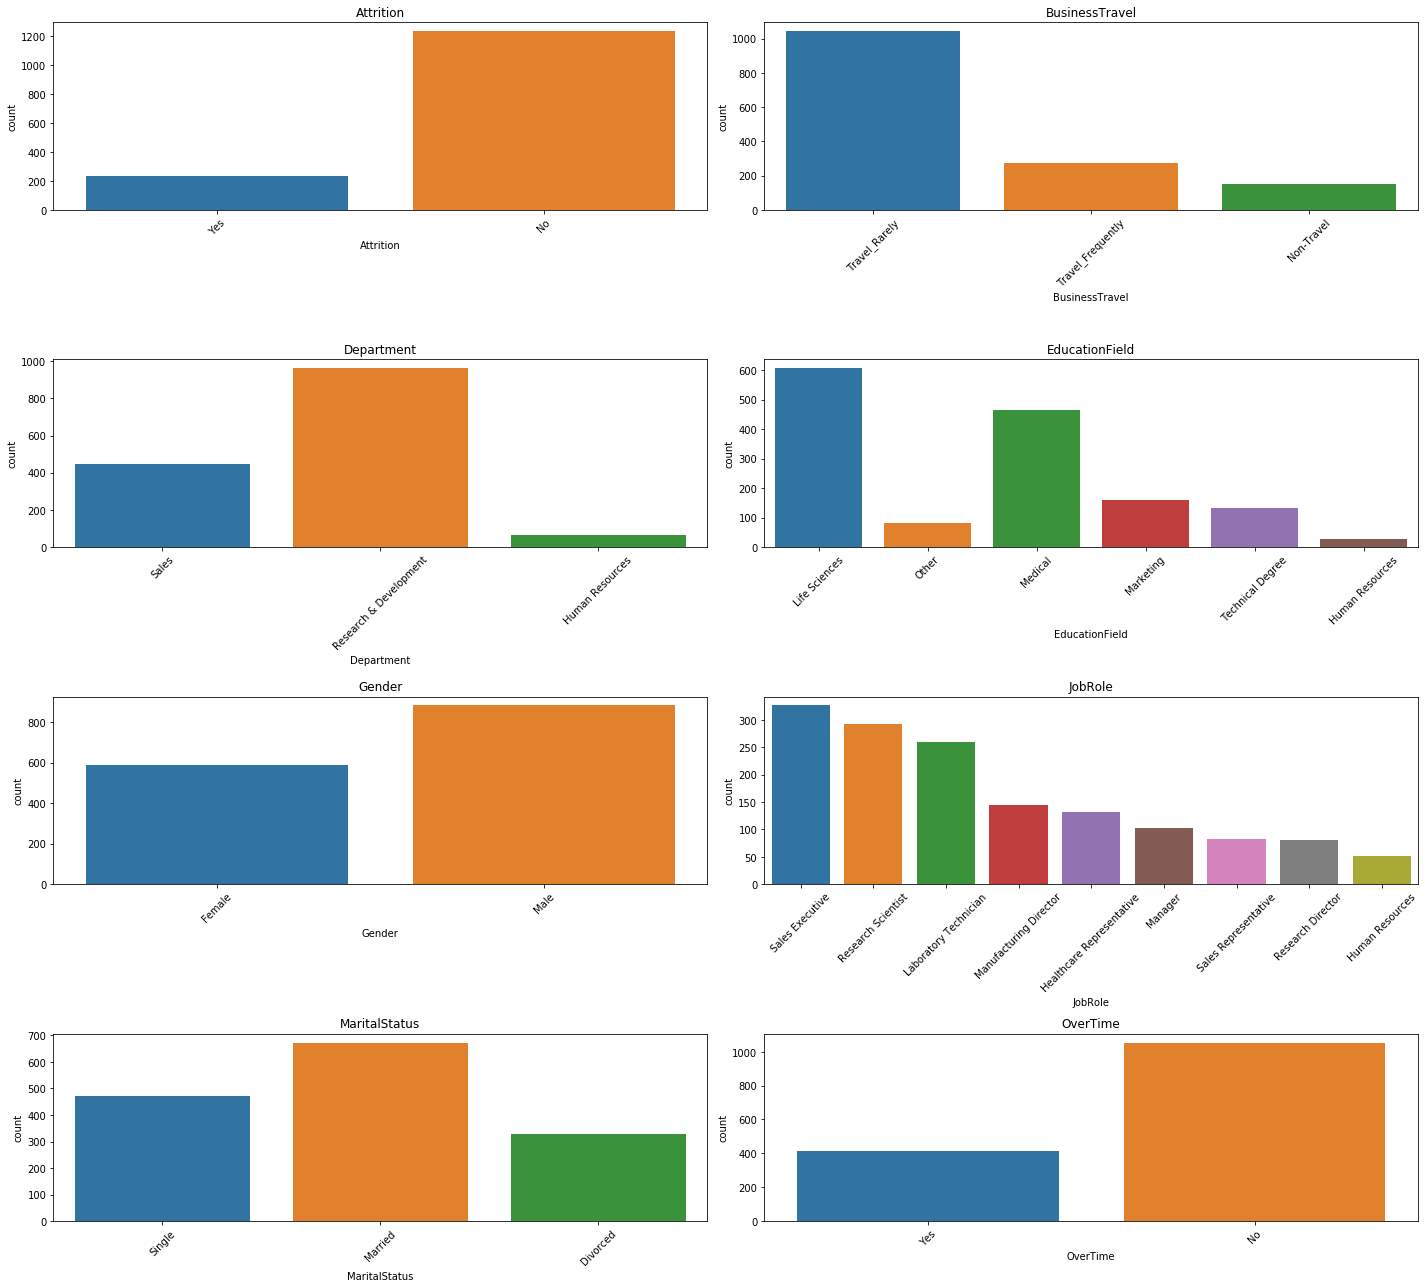

In [18]:
plt.figure(figsize=(20,18))

for i, col in enumerate(cat_cols):
    plt.subplot(4,2,i+1)
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### Observations
--> Attrition (Target Variable) : moderately imbalanced, Employee attrition is naturally less frequent than retention.

--> BusinessTravel : Most employees travel occasionally, while relatively few travel frequently.

--> Department : Research & Development has the highest number of employees, followed by Sales, while Human Resources has the fewest.This is expected in many organizations where R&D forms the core workforce.

--> EducationField : The company hires many employees from science-related backgrounds.

--> Gender : There is a slight gender imbalance, but both classes are well represented.

--> JobRole : The workforce is concentrated in operational roles rather than managerial positions.

--> MaritalStatus : Marital status may influence employee retention, making it an interesting feature for later analysis.

--> OverTime : OverTime is often one of the strongest predictors of employee attrition, so this feature deserves special attention during bivariate analysis.

Overall Observations:

Target (Attrition) is moderately imbalanced.
Most employees travel rarely.
R&D is the largest department.
Life Sciences is the dominant education field.
Sales Executive is the most common job role.
Married employees are the largest marital status group.
Most employees do not work overtime.

No category appears suspicious or requires removal.

### Bivariate Analysis

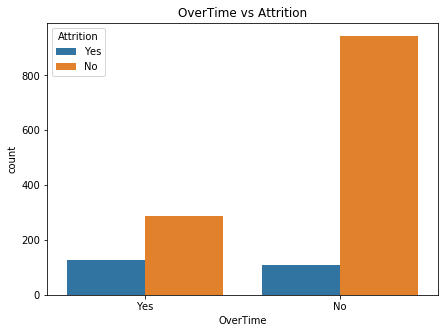

In [19]:
# OverTime vs Attrition

plt.figure(figsize=(7,5))
sns.countplot(data=df
             ,x='OverTime',
            hue='Attrition')
plt.title("OverTime vs Attrition")
plt.show()

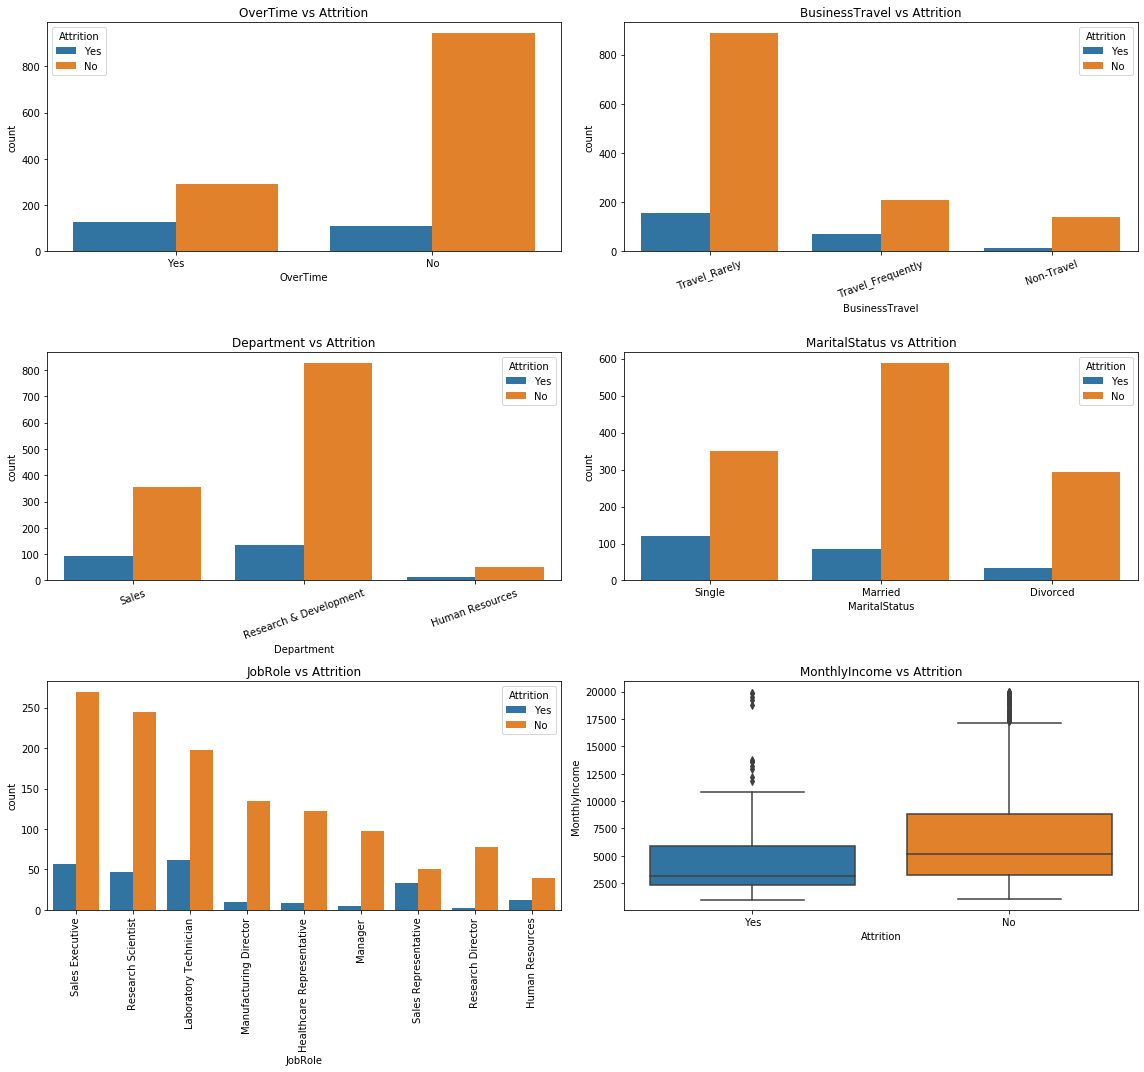

In [20]:
# Plotting all together

fig, axes = plt.subplots(3, 2, figsize=(16, 15))

# 1
sns.countplot(data=df, x='OverTime', hue='Attrition', ax=axes[0,0])
axes[0,0].set_title("OverTime vs Attrition")

# 2
sns.countplot(data=df, x='BusinessTravel', hue='Attrition', ax=axes[0,1])
axes[0,1].set_title("BusinessTravel vs Attrition")
axes[0,1].tick_params(axis='x', rotation=20)

# 3
sns.countplot(data=df, x='Department', hue='Attrition', ax=axes[1,0])
axes[1,0].set_title("Department vs Attrition")
axes[1,0].tick_params(axis='x', rotation=20)

# 4
sns.countplot(data=df, x='MaritalStatus', hue='Attrition', ax=axes[1,1])
axes[1,1].set_title("MaritalStatus vs Attrition")

# 5
sns.countplot(data=df, x='JobRole', hue='Attrition', ax=axes[2,0])
axes[2,0].set_title("JobRole vs Attrition")
axes[2,0].tick_params(axis='x', rotation=90)

# 6
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[2,1])
axes[2,1].set_title("MonthlyIncome vs Attrition")

plt.tight_layout()

plt.show()

--> OverTime vs Attrition:

Employees not doing overtime have much lower attrition.
Employees working overtime have a noticeably higher proportion of attrition.
Employees working overtime are considerably more likely to leave the organization, suggesting overtime is an important predictor of employee attrition.

--> BusinessTravel vs Attrition

Frequent business travel appears positively associated with employee attrition, while employees who rarely or never travel tend to stay longer.

--> Department vs Attrition

R&D has the highest number of employees as well as the highest number of attrition cases. Attrition rate should be checked before concluding that R&D employees are more likely to leave.

--> MaritalStatus vs Attrition

Single employees exhibit relatively higher attrition compared to married employees.

--> JobRole vs Attrition : This is one of the most informative plots.

Operational and customer-facing roles show comparatively higher attrition than managerial and leadership roles.

--> MonthlyIncome vs Attrition : This is one of the strongest plots.

Employees with lower monthly income exhibit significantly higher attrition, indicating salary is an important factor influencing employee retention.



From these six plots, the strongest potential predictors of attrition appear to be:

⭐ Monthly Income
⭐ Overtime
⭐ Job Role
Business Travel
Marital Status
Department (requires attrition rate analysis before strong conclusions)

#### Encoding Categorical variables

Before building a Random Forest model, we need to convert categorical columns into numbers because machine learning algorithms cannot work directly with text.

In [21]:
# All categorical cols

cat_cols

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')

* Why do we separate X and y before encoding?

Because Attrition is the variable we want to predict. We should only encode the input features (X), while handling the target separately.

In [22]:
# Separate target variable
X = df.drop('Attrition',axis=1)
y = df['Attrition']

In [23]:
# One-Hot Encode Features
X = pd.get_dummies(X,drop_first= True,dtype = int)

In [24]:
#Encode Target Variable
y = y.map({'Yes':1,'No':0})

Why didn't we use get_dummies() for the target?

Because the target has only two classes. Mapping directly to 0 and 1 is simpler, cleaner, and is the standard practice for binary classification.

In [25]:
print(X.shape)

print(y.shape)

(1470, 44)
(1470,)


In [26]:
print(y.head())
print(X.head())

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64
   Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
0   41       1102                 1          2                        2   
1   49        279                 8          1                        3   
2   37       1373                 2          2                        4   
3   33       1392                 3          4                        4   
4   27        591                 2          1                        1   

   HourlyRate  JobInvolvement  JobLevel  JobSatisfaction  MonthlyIncome  ...  \
0          94               3         2                4           5993  ...   
1          61               2         2                2           5130  ...   
2          92               2         1                3           2090  ...   
3          56               3         1                3           2909  ...   
4          40               3         1                2           3468  ...   

   

In [27]:
# Train - Test split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
# Verify the split

print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(1176, 44)
(294, 44)
(1176,)
(294,)


#### Build the first random forest model (baseline)

In [29]:
from sklearn.ensemble import RandomForestClassifier

In [30]:
rf = RandomForestClassifier(random_state=42)

Why only random_state=42?

We want to build the default Random Forest first.

This is called our Baseline Model.

Only after knowing the baseline performance do we tune hyperparameters.

In [31]:
# Train the model

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [32]:
# make predictions

y_pred = rf.predict(X_test)

In [33]:
# Evaluate the model

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [34]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8775510204081632

Confusion Matrix:
[[254   1]
 [ 35   4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294



In [35]:
# check for overfitting

train_pred = rf.predict(X_train)

print(
    "Training Accuracy:",
    accuracy_score(y_train, train_pred)
)

Training Accuracy: 1.0


***

Random Forest often achieves a very high training accuracy because it contains many deep decision trees.

This is not automatically a problem.

The key is to compare it with the test accuracy.

If the gap is small, the model generalizes well.

##### Observations
Although the model achieves 87.8% accuracy, it performs poorly in identifying employees who actually leave.

It predicts the majority class ("No Attrition") very well but fails to capture the minority class ("Yes Attrition"), resulting in very low recall.

This is a classic example of class imbalance.

In [36]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

0    978
1    198
Name: Attrition, dtype: int64
0    0.831633
1    0.168367
Name: Attrition, dtype: float64


This means

Out of every 100 employees

83 stay
17 leave

The dataset is imbalanced, although not extremely imbalanced.

Why did Random Forest perform poorly?

Think like the algorithm.

Suppose it predicts:

No
No
No
No
No
No
No
No

It is already correct 83% of the time.

So it naturally becomes biased toward predicting

No Attrition

instead of learning the minority class.

That is exactly why your confusion matrix looked like:

Actual Yes = 39

Predicted Yes = only 4

It simply avoided predicting "Yes".

In [37]:
# building an improved random forest model
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

rf_balanced.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

What does class_weight='balanced' do?

Instead of treating every mistake equally, the algorithm gives more importance to mistakes on the minority class.

Conceptually:

Instead of

Mistake on No  = 1 point

Mistake on Yes = 1 point

it becomes something like

Mistake on No  = 1 point

Mistake on Yes = 5 points

(The exact weights are calculated automatically based on class frequencies.)

This encourages the model to pay more attention to employees who actually leave.

In [38]:
# Again, evaluate the model
y_pred_balanced = rf_balanced.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

Accuracy: 0.8741496598639455

Confusion Matrix:
[[254   1]
 [ 36   3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.75      0.08      0.14        39

    accuracy                           0.87       294
   macro avg       0.81      0.54      0.54       294
weighted avg       0.86      0.87      0.83       294



In [39]:
train_pred_balanced = rf_balanced.predict(X_train)

print(
    "Training Accuracy:",
    accuracy_score(y_train, train_pred_balanced)
)

Training Accuracy: 1.0


* What happened?

Instead of improving,

the model became slightly worse.

Recall dropped from

10%

↓

8%

Does class_weight always improve the model?
Answer

No.

This is a very common misconception.

Many beginners think

class_weight='balanced'

automatically improves recall.

It does not.

It only tells the algorithm:

"Pay more attention to the minority class."

Whether performance improves depends on:

dataset characteristics
feature quality
class separability
model complexity

Sometimes it improves.

Sometimes nothing changes.

Sometimes it even gets worse.

That is exactly what happened here.

#### Next step, Feature Importance

Which features influenced the Random Forest the most?

In [40]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
9,MonthlyIncome,0.079447
43,OverTime_Yes,0.058897
0,Age,0.056085
1,DailyRate,0.051504
10,MonthlyRate,0.048895
16,TotalWorkingYears,0.048578
2,DistanceFromHome,0.042809
5,HourlyRate,0.041754
19,YearsAtCompany,0.041551
11,NumCompaniesWorked,0.037947


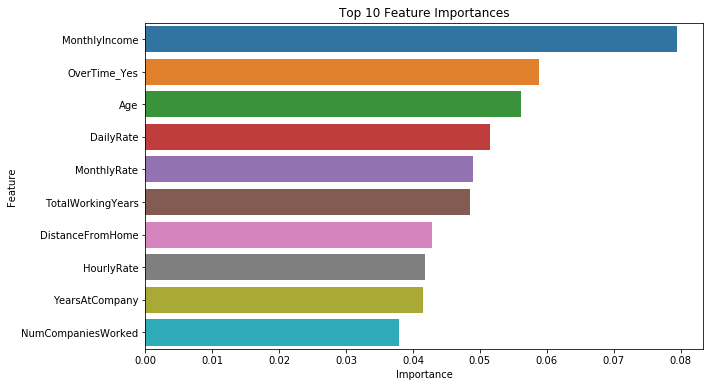

In [41]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Feature Importances")
plt.show()

In [42]:
# Hyperparameter Tuning using GridSearchCV

from sklearn.model_selection import GridSearchCV

In [43]:
# Create Parameter Grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

In [44]:
# Create GridSearchCV

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

Earlier we mainly optimized for  accuracy.

For the attrition dataset, our problem is class imbalance, and we observed that accuracy was misleading.

Using F1-score balances precision and recall, making it a better choice here.

In [45]:
# Train GridSearchCV
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None], 'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [46]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
0.3323960062980199


In [47]:
# building the tuned model

best_rf = grid.best_estimator_

In [48]:
# make predictions

y_pred_best = best_rf.predict(X_test)

In [49]:
# Evaluate the Model

print("Accuracy:", accuracy_score(y_test, y_pred_best))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Accuracy: 0.8775510204081632

Confusion Matrix:
[[254   1]
 [ 35   4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294



In [50]:
# check for overfitting

train_pred_best = best_rf.predict(X_train)

print("Training Accuracy:",
      accuracy_score(y_train, train_pred_best))

Training Accuracy: 1.0


# Analyze the model

Your tuned model produced exactly the same results as the baseline model.

| Metric            | Baseline RF | Tuned RF |
| ----------------- | ----------: | -------: |
| Training Accuracy |        100% |     100% |
| Test Accuracy     |      87.76% |   87.76% |
| Precision (Yes)   |        0.80 |     0.80 |
| Recall (Yes)      |        0.10 |     0.10 |
| F1-score (Yes)    |        0.18 |     0.18 |


Did GridSearchCV fail?

Answer

No.

It found that the best-performing combination within the parameter grid was essentially the same as the default model.

### Improving random forest

Why would you optimize Recall instead of Accuracy in an employee attrition model?

Answer

Because the business goal is to identify employees at risk of leaving. Missing a resigning employee (False Negative) is more costly than incorrectly flagging an employee who ultimately stays (False Positive). Therefore, Recall is the more appropriate optimization metric.

#### Step 1: Recall-Based GridSearchCV

In [52]:
# create the grid

param_grid_recall = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt']
}

In [53]:
# Optimize for Recall instead of F1

grid_recall = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_recall,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

In [55]:
# fit
grid_recall.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200]},
             scoring='recall')

In [56]:
print(grid_recall.best_params_)
print(grid_recall.best_score_)


{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
0.2117948717948718


Q. Why is grid.best_score_ different from the Recall on the test set?
Answer

grid.best_score_ is the mean cross-validation Recall calculated on the training data during hyperparameter tuning. The Recall reported after prediction is calculated on the separate test dataset. Since they are evaluated on different data, different values are expected.

In [57]:
# Step 15 – Build the Recall-Optimized Model

best_rf_recall = grid_recall.best_estimator_

In [58]:
# Make Predictions

y_pred_recall = best_rf_recall.predict(X_test)

In [59]:
# Evaluate

print("Accuracy:", accuracy_score(y_test, y_pred_recall))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_recall))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_recall))

Accuracy: 0.8775510204081632

Confusion Matrix:
[[254   1]
 [ 35   4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294



In [60]:
# Training accuracy

train_pred_recall = best_rf_recall.predict(X_train)

print(
    "Training Accuracy:",
    accuracy_score(y_train, train_pred_recall)
)

Training Accuracy: 1.0


Changing the hyperparameters did not change the model's predictions.

This raises an important question
Why?

There are several possibilities:

The dataset is moderately imbalanced (84% vs 16%).
The default probability threshold (0.5) is too conservative.
The features don't separate the minority class strongly enough.
Hyperparameter tuning isn't addressing the real issue.

### Threshold Tuning

In [61]:
# Let's See the Probabilities


y_prob = best_rf.predict_proba(X_test)

y_prob[:10]

array([[0.835, 0.165],
       [0.935, 0.065],
       [0.605, 0.395],
       [0.95 , 0.05 ],
       [0.93 , 0.07 ],
       [0.655, 0.345],
       [0.86 , 0.14 ],
       [0.885, 0.115],
       [0.84 , 0.16 ],
       [0.73 , 0.27 ]])

predict_proba() returns:

[
 [P(No), P(Yes)],
 [P(No), P(Yes)],
 ...
]

In [63]:
# Extract Only the Probability of Leaving ,We only care about the probability of Attrition = Yes.

y_prob = best_rf.predict_proba(X_test)[:,1]
y_prob[:10]

array([0.165, 0.065, 0.395, 0.05 , 0.07 , 0.345, 0.14 , 0.115, 0.16 ,
       0.27 ])

Currently,Scikit-learn says

Need at least 50% confidence -- > Predict Leave

Suppose we change the rule. Instead of 50% we say 30%.

Now

Employee 3

39.5% > 30% :  becomes Leave

Employee 6

34.5% > 30% : also becomes leave.

Without retraining the model, we have already identified two additional employees at risk.This is the power of threshold tuning.

#### Business Analogy

Imagine you're an airport security officer.

If you only stop passengers when you're 100% sure they're carrying something suspicious, you'll miss many threats.

Instead, you lower the threshold:

"If I'm 30% suspicious, I'll do an extra check."

You'll stop more innocent passengers (more False Positives), but you'll also catch more real threats (higher Recall).

The same principle applies here.

In [64]:
# Let's Experiment ,Now we'll compare different thresholds.

from sklearn.metrics import classification_report

thresholds = [0.5, 0.4, 0.3, 0.2]

for threshold in thresholds:
    
    y_pred_threshold = (y_prob >= threshold).astype(int)

    print("=" * 50)
    print(f"Threshold = {threshold}")
    print("=" * 50)

    print(classification_report(y_test, y_pred_threshold))

Threshold = 0.5
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294

Threshold = 0.4
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       255
           1       0.45      0.13      0.20        39

    accuracy                           0.86       294
   macro avg       0.67      0.55      0.56       294
weighted avg       0.82      0.86      0.83       294

Threshold = 0.3
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       255
           1       0.34      0.33      0.34        39

    accuracy                           0.83       294
   macro avg       0.62      0.62      0.62       294
weighted avg       0.82   


###### Threshold Tuning Analysis

Let's create a comparison table

| Threshold |  Accuracy | Precision (Yes) | Recall (Yes) | F1 (Yes) |
| --------- | --------: | --------------: | -----------: | -------: |
| **0.50**  | **87.8%** |        **0.80** |     **0.10** | **0.18** |
| **0.40**  | **86.0%** |        **0.45** |     **0.13** | **0.20** |
| **0.30**  | **83.0%** |        **0.34** |     **0.33** | **0.34** |
| **0.20**  | **73.0%** |        **0.28** |     **0.64** | **0.39** |


Threshold = 0.50 (Default)
Observation
Highest accuracy
Excellent precision
Very poor recall

The model identifies only 10% of employees who actually leave.

Business Interpretation

This model is very conservative.

It predicts "Leave" only when it's extremely confident.

Result:

Very few false alarms.
But it misses most resignations.
Threshold = 0.40
Observation
Accuracy drops slightly.
Recall improves a little.
Precision decreases.
Business Interpretation

We're becoming slightly more willing to investigate employees who may leave.

Still, the improvement is modest.

Threshold = 0.30 ⭐
Observation
Accuracy: 83%
Recall jumps to 33%
F1 almost doubles from 0.18 → 0.34

This is a significant improvement.

Business Interpretation

We're identifying one out of every three employees who leave instead of only one out of ten.

Threshold = 0.20 ⭐⭐⭐⭐

Accuracy decreased but recall increased drastically.
Earlier:

Out of 39 employees who resigned,we found only:
4

Now:

Recall = 64% , Approximately 25 employees would be identified.
That's a huge improvement.

But the precision dropped.

So, the threshold depends on business totally whether they want to focus on false negatives or false positives.

Here, threshold 0.30 offers a more balanced trade-off.

#### Observation

"The default threshold of 0.5 prioritized overall accuracy but missed most employees who resigned. Since the business objective is employee retention, I experimented with decision threshold tuning. Reducing the threshold to 0.3 significantly improved Recall while maintaining a reasonable overall accuracy, making it a more suitable choice for the HR use case."

### ROC Curve & AUC

Q. Why do we use ROC Curve?
Answer

ROC Curve evaluates the performance of a classification model across all possible decision thresholds. It helps us understand how well the model separates the positive and negative classes without depending on a single threshold.

In [65]:
# import
from sklearn.metrics import roc_curve, roc_auc_score

In [67]:
# Compute ROC, tpr(recall)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [68]:
# Calculate AUC
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.7569632981397687


Q. What is AUC?

AUC (Area Under the ROC Curve) measures how well a model distinguishes between classes.

Higher AUC indicates better class separation.

Here, About 76% of the time, the model gives a higher probability to the employee who actually left than to the employee who stayed.

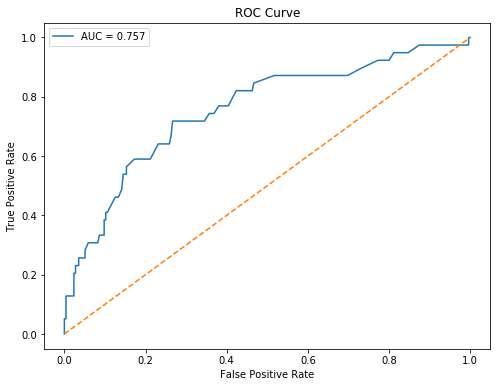

In [69]:
# Plot ROC
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

ROC Curve:

The blue curve stays well above the diagonal baseline.
The curve rises quickly near the left side, which means the model achieves a reasonably high True Positive Rate before accumulating many False Positives.
It is clearly better than random guessing, although there is still room for improvement.

### Final model comparison

| Model                  | Train Accuracy | Test Accuracy |   Recall | Precision |       F1 |   ROC-AUC |
| ---------------------- | -------------: | ------------: | -------: | --------: | -------: | --------: |
| Baseline Random Forest |     **100.0%** |    **87.76%** | **0.10** |  **0.80** | **0.18** | **0.757** |
| GridSearchCV (F1)      |     **100.0%** |    **87.76%** | **0.10** |  **0.80** | **0.18** | **0.757** |
| Threshold = 0.30       | **Same Model** |     **83.0%** | **0.33** |  **0.34** | **0.34** | **0.757** |
| Threshold = 0.20       | **Same Model** |     **73.0%** | **0.64** |  **0.28** | **0.39** | **0.757** |
